# Inference Notebook for Scenarios with Existing Ground Truth

**How it works:** Choose a setup for the simulation and select a GNO checkpoint.
The Notebook will automatically generate the mesh, compute the GNO prediction and produce varios visualizations.



## How the Setup Works

A scenario is fully described by three parameters:
- The NACA code which defines the geometry of the airfoil
- The Reynolds number
- Angle of attack [deg]

Based on these three settings, the remaining variables are computed. We use normalization based on airfoil width to stabilize training. The remaining quantities are defined as follows:

- airfoil width: $chord = 1m$ $\quad \rightarrow$ this is the basis for normalization and remains constant across all samples
- kinematic viscosity: $\nu = 1.0e^{-5} m²/s$
- freestream velocity: $ u = \frac{Re * \nu}{chord} $



### Scenario and Setup

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from surrogate.gno.infer import infer
from surrogate.gno.graph import select_device
from utils.inference.fields import plot_scalar_field, plot_velocity_streamlines
from utils.inference.error_maps import plot_error_map
from utils.inference.io import save_predictions_npz
from utils.scenario import build_scenario

# --- scenario definition ---
naca_code = "2210"
reynolds = 210000
angle_of_attack = -4.9

# --- run configuration ---
checkpoint = Path("checkpoints/gno_w32_d6_k16_lr0.001_NACA_4_Digit_for_ML/best.pt")
save_prediction_to = None        # set to a .npz path to save GNO predictions
save_mesh_to = Path("output/custom_mesh.h5")   # set to None to skip mesh saving
device = select_device()         # cuda -> mps -> cpu

# --- build scenario in memory (mesh + per-node features) ---
scenario = build_scenario(naca_code, reynolds, angle_of_attack, save_mesh_to=save_mesh_to, device=device)

# --- run inference ---
result = infer(scenario, checkpoint, device=device)
if save_prediction_to is not None:
    save_predictions_npz(result, save_prediction_to)


Saved mesh → output/custom_mesh.h5
Building graph (k=16)...
  1,241,472 edges  (0.1s)
Running inference...


  Done in 0.13s


## Field Visualizations

### Velocity Magnitude ($|u|_2$)

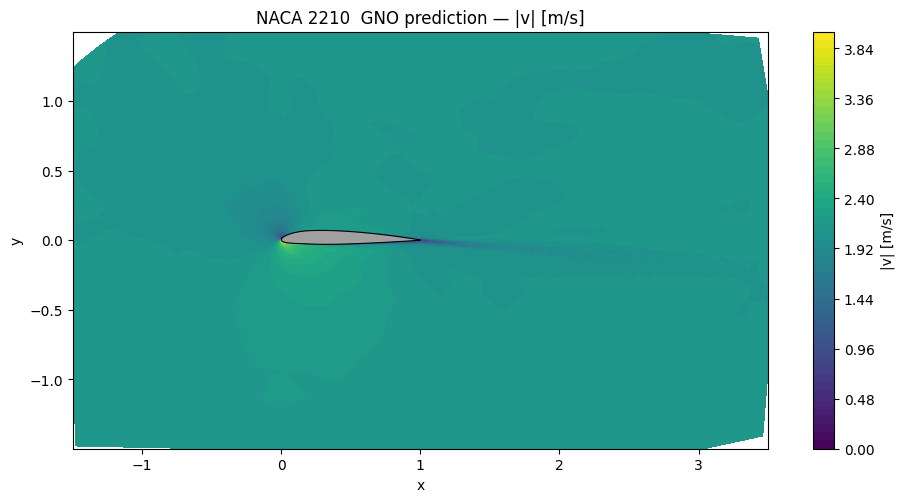

In [2]:
plot_scalar_field(result, "vel_mag")
plt.show()


### Velocity Streamlines

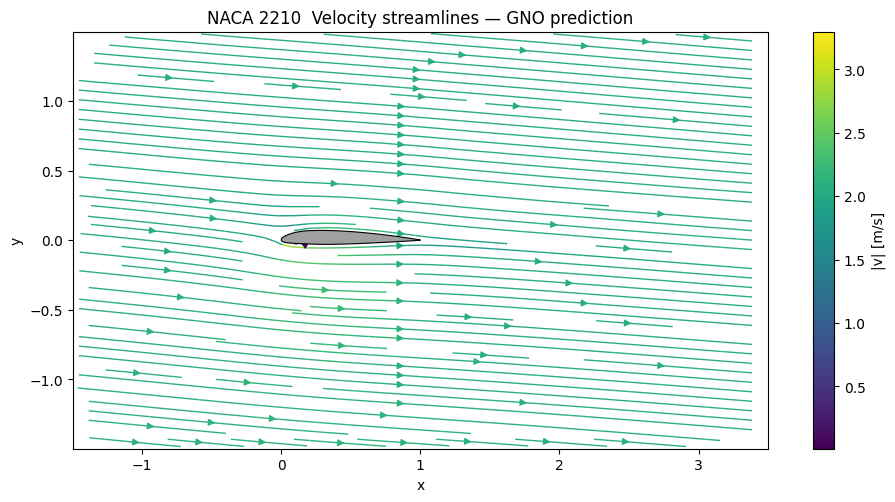

In [3]:
plot_velocity_streamlines(result)
plt.show()


### Pressure Field ($p$)

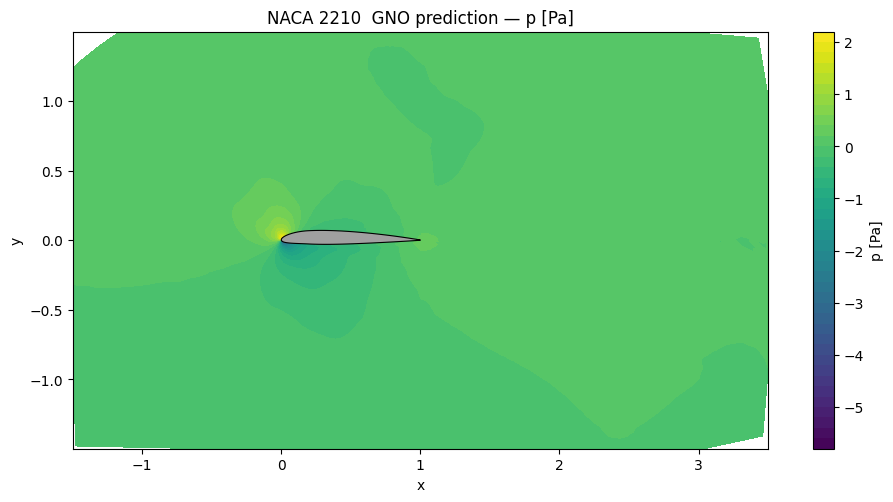

In [4]:
plot_scalar_field(result, "p")
plt.show()


### Turbulent Kinetic Energy ($k$)

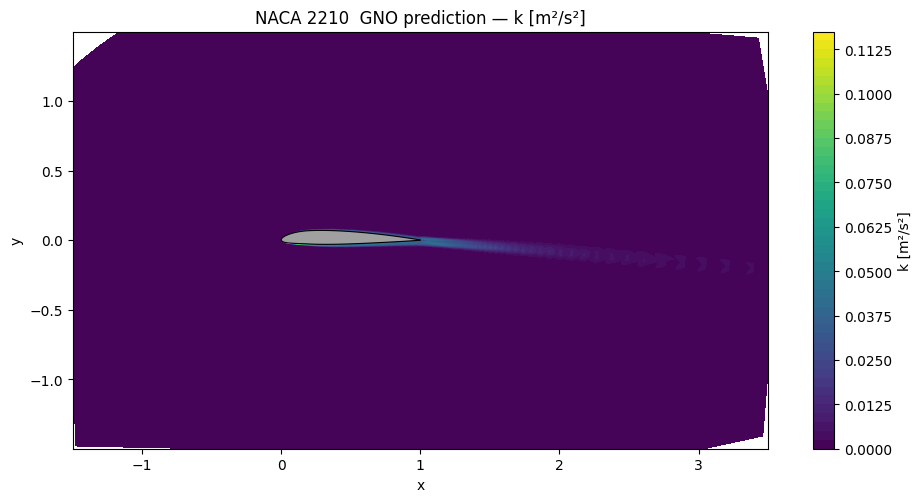

In [5]:
plot_scalar_field(result, "k")
plt.show()


### Specific Dissipation Rate ($\omega$)

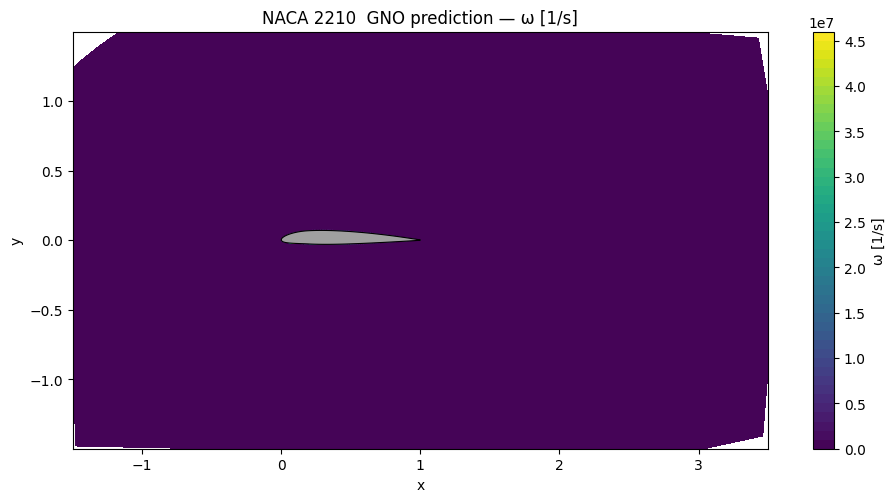

In [6]:
plot_scalar_field(result, "omega")
plt.show()


### Turbulent Viscosity ($\nu_t$)

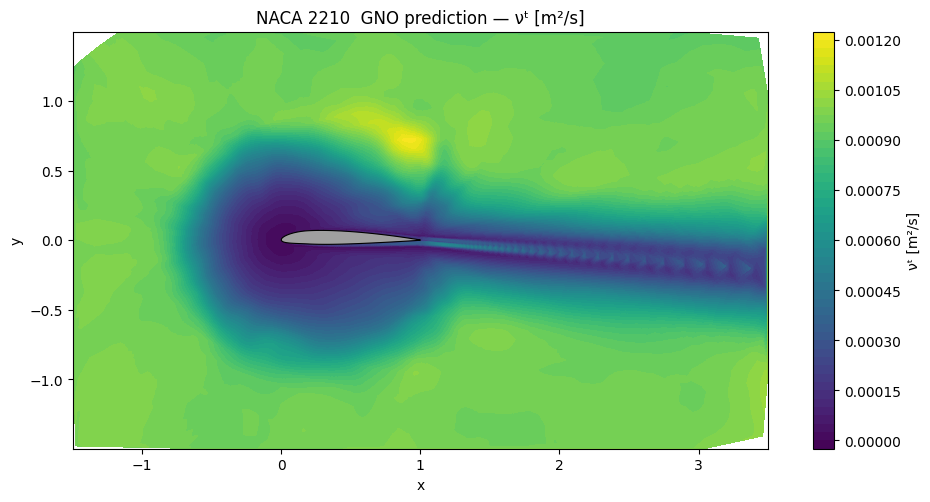

In [7]:
plot_scalar_field(result, "nut")
plt.show()
